<h1 style="text-align: center;">Dengue Dataset Analysis</h1>


![Alt Text](dengue.avif)


<h2>Importing</h2>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

dengue = pd.read_csv('datasets\\dengue.csv')
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


<h2>Check the  dataset info</h2>

dengue.info()

<h2>Check the null values</h2>

In [2]:
dengue.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

<h2>Change the data types name</h2>


In [3]:
dengue['Month'] = dengue['Month'].astype('category')
dengue['Year'] = dengue['Year'].astype('category')
dengue['Region'] = dengue['Region'].astype('category')
dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Month          1020 non-null   category
 1   Year           1020 non-null   category
 2   Region         1020 non-null   category
 3   Dengue_Cases   1020 non-null   int64   
 4   Dengue_Deaths  1020 non-null   int64   
dtypes: category(3), int64(2)
memory usage: 20.3 KB


<h2 style="text-align:center;">10 Insights</h2>

<h2>1.What is the overall trend of dengue cases and deaths from 2016 to 2020?</h2>

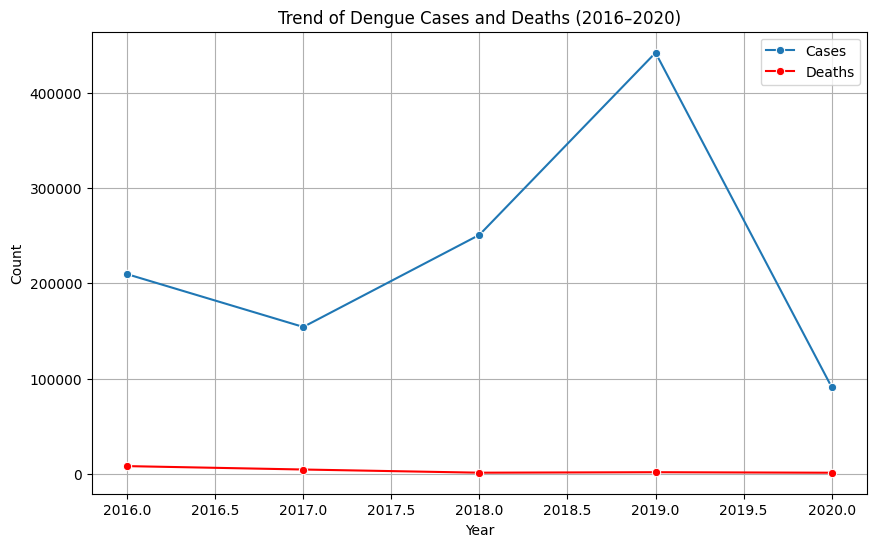

In [4]:
trend = dengue.groupby('Year')[['Dengue_Cases', 'Dengue_Deaths']].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=trend, x='Year', y='Dengue_Cases', marker='o', label='Cases')
sns.lineplot(data=trend, x='Year', y='Dengue_Deaths', marker='o', label='Deaths', color='red')
plt.title('Trend of Dengue Cases and Deaths (2016–2020)')
plt.ylabel('Count')
plt.grid(True)
plt.show()


<h2>Insight #1</h2>
<h3>Dengue cases peaked in 2019 at more than 440k, marking the most severe year within the period.
<h2>Insight #2</h2>
<h3>
Deaths decreased significantly after 2016, showing improved medical treatment and awareness.</h3>

<h2>2.Which regions reported the most dengue cases overall 2016–2020?</h2>

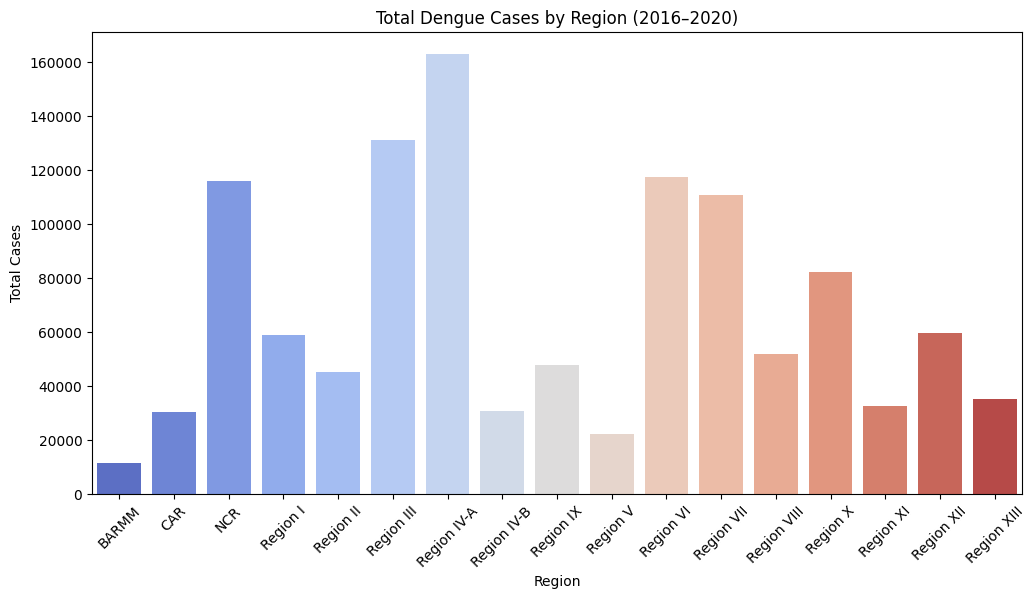

In [5]:
region_total = dengue.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=region_total, x='Region', y='Dengue_Cases', palette='coolwarm')
plt.title('Total Dengue Cases by Region (2016–2020)')
plt.xticks(rotation=45)
plt.ylabel('Total Cases')
plt.show()


<h2>Insight #1</h2>
<h3>A few regions dominate in dengue cases, showing geographical concentration of outbreaks.
<h2>Insight #2</h2>
<h3>
These high case regions may require intensive vector control programs and early alert systems.</h3>

<h2>3.How did dengue cases change by month across all years?</h2>

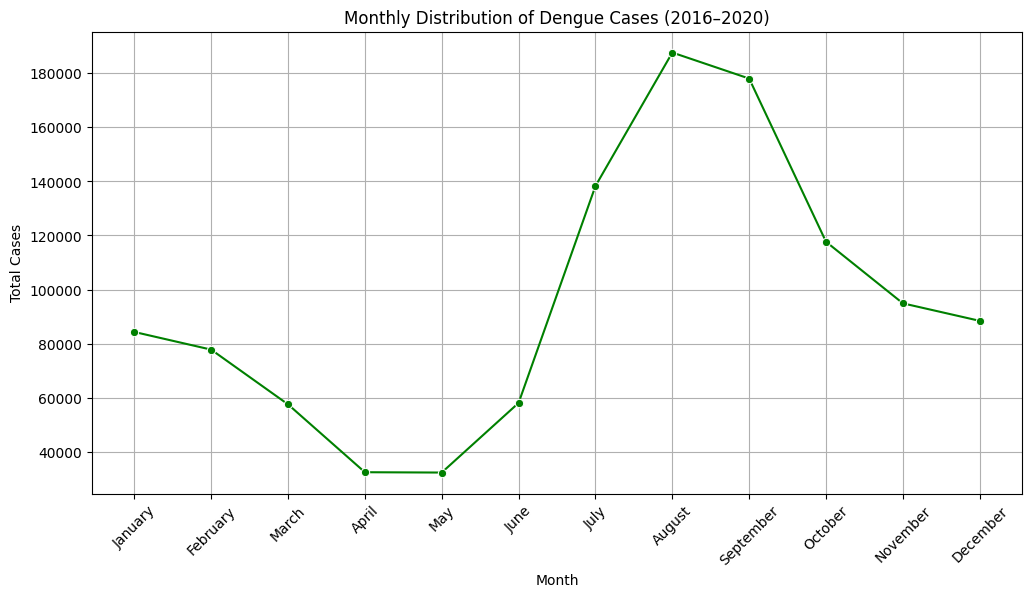

In [6]:
monthly = dengue.groupby('Month')['Dengue_Cases'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='Month', y='Dengue_Cases', marker='o', color='green')
plt.title('Monthly Distribution of Dengue Cases (2016–2020)')
plt.xticks(rotation=45)
plt.ylabel('Total Cases')
plt.grid(True)
plt.show()


<h2>Insight #1</h2>
<h3>Cases start increasing around June and peak between August–October, aligning with the rainy season.
<h2>Insight #2</h2>
<h3>
The dengue trend confirms seasonality, suggesting that weather plays a key role in mosquito breeding.</h3>

<h2>4.What is the average dengue mortality rate in each region 2016–2020?</h2>

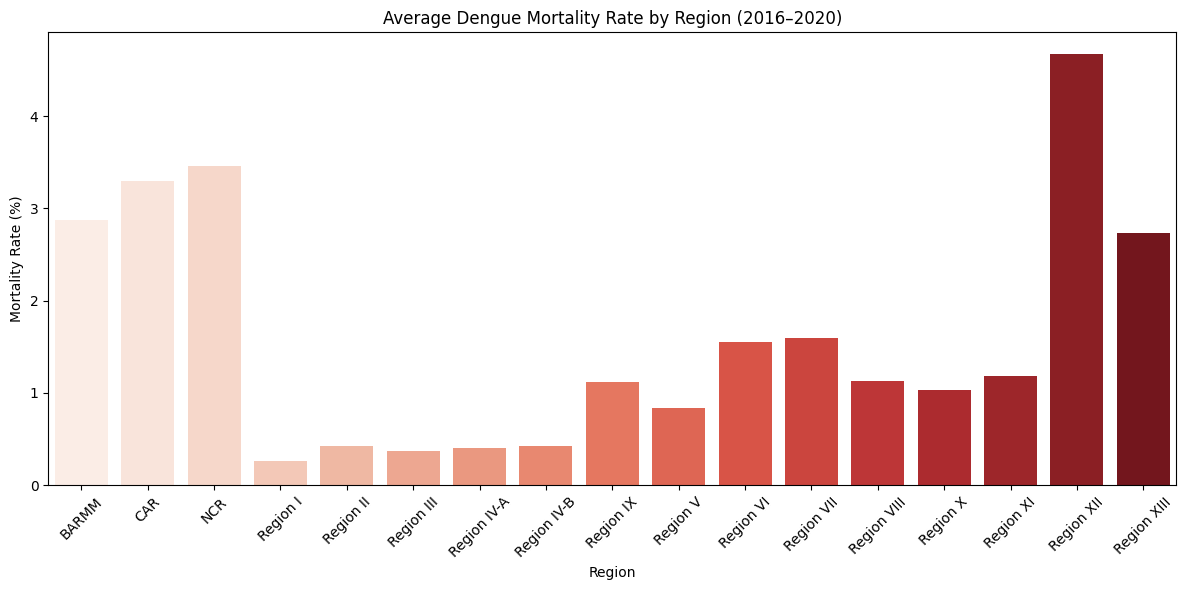

,Region,Dengue_Cases,Dengue_Deaths,Mortality_Rate
0,Region XII,59802,2796,4.675429
1,NCR,115966,4008,3.456185
2,CAR,30582,1008,3.296057
3,BARMM,11537,332,2.877698
4,Region XIII,35293,966,2.737087


In [7]:
# Compute mortality rate per region
# Mortality rate = (Total Deaths / Total Cases) * 100
region_mortality = (
    dengue.groupby('Region')[['Dengue_Cases', 'Dengue_Deaths']]
    .sum()
    .assign(Mortality_Rate=lambda x: (x['Dengue_Deaths'] / x['Dengue_Cases']) * 100)
    .sort_values(by='Mortality_Rate', ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=region_mortality, x='Region', y='Mortality_Rate', palette='Reds')
plt.title('Average Dengue Mortality Rate by Region (2016–2020)')
plt.xlabel('Region')
plt.ylabel('Mortality Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

region_mortality.head()


<h2>Insight #1</h2>
<h3>Some regions show higher mortality rates despite fewer cases, suggesting unequal access to healthcare or delayed treatment.
<h2>Insight #2</h2>
<h3>Regions with lower mortality rates likely benefit from better disease monitoring, hospital capacity, and public awareness.</h3>

<h2>5.In high case regions, is there a correlation between cases and deaths?</h2>

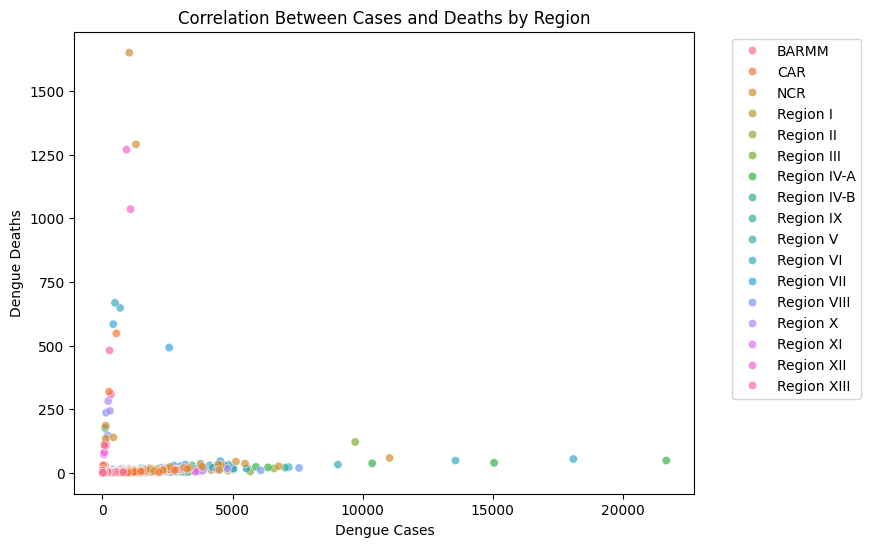

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dengue, x='Dengue_Cases', y='Dengue_Deaths', hue='Region', alpha=0.7)
plt.title('Correlation Between Cases and Deaths by Region')
plt.xlabel('Dengue Cases')
plt.ylabel('Dengue Deaths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


<h2>Insight #1</h2>
<h3>A positive correlation exists in regions with more cases also tend to record more deaths.
<h2>Insight #2</h2>
<h3>But some regions show high cases but low deaths, reflecting effective medical systems or reporting differences.</h3>